In [1]:
from typing import Dict, List, TypedDict
from langgraph.graph import StateGraph, START, END
import random

In [2]:
class AgentState(TypedDict):
  name: str
  number: List[int]
  counter: int

In [3]:
def greeting_node(state: AgentState) -> AgentState:
  """This node is used to greet the user"""
  
  state['name'] = f"Hi there, {state['name']}"
  state['counter'] = 0
  return state

def random_node(state: AgentState) -> AgentState:
  """This node generate random number from 0 to 10"""
  
  state['number'].append(random.randint(0, 10))
  state['counter'] += 1
  return state

def should_continue(state: AgentState) -> AgentState:
  """Function to decide the next node of the graph"""
  
  if state['counter'] < 5:
    print("Entering LOOP", state['counter'])
    return "loop"
  else:
    return "exit"

In [4]:
graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)

graph.add_edge("greeting", "random")

graph.add_conditional_edges(
  "random",
  should_continue,
  {
    "loop": "random",
    "exit": END
  }
)

graph.set_entry_point("greeting")

app = graph.compile()

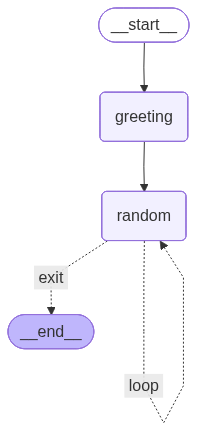

In [5]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
app.invoke({"name":"Samarth","number":[], "counter":"-1"})x

Entering LOOP 1
Entering LOOP 2
Entering LOOP 3
Entering LOOP 4


{'name': 'Hi there, Samarth', 'number': [1, 1, 3, 5, 9], 'counter': 5}